# Import Libaries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('gld_price_data.csv')

In [3]:
df.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [4]:
df.tail()

,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


In [5]:
df.sample(6)

,Date,SPX,GLD,USO,SLV,EUR/USD
1738,11/24/2015,2089.139893,102.940002,13.320000,13.510000,1.064203
1004,7/30/2012,1385.300049,157.429993,33.450001,27.360001,1.225941
2150,10/9/2017,2544.729980,122.080002,10.000000,16.020000,1.174164
2184,12/4/2017,2639.439941,121.180000,11.490000,15.440000,1.185986
1752,12/15/2015,2043.410034,101.519997,11.400000,13.110000,1.099300
973,6/4/2012,1278.180054,157.320007,31.760000,27.459999,1.250938


In [6]:
df.shape

(2290, 6)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [8]:
df.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


In [9]:
df.isnull().sum()

Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.columns

Index(['Date', 'SPX', 'GLD', 'USO', 'SLV', 'EUR/USD'], dtype='object')

In [13]:
# correlation
correlation = df.corr(numeric_only = True)

In [14]:
correlation

,SPX,GLD,USO,SLV,EUR/USD
SPX,1.000000,0.049345,-0.591573,-0.274055,-0.672017
GLD,0.049345,1.000000,-0.186360,0.866632,-0.024375
USO,-0.591573,-0.186360,1.000000,0.167547,0.829317
SLV,-0.274055,0.866632,0.167547,1.000000,0.321631
EUR/USD,-0.672017,-0.024375,0.829317,0.321631,1.000000


<Axes: >

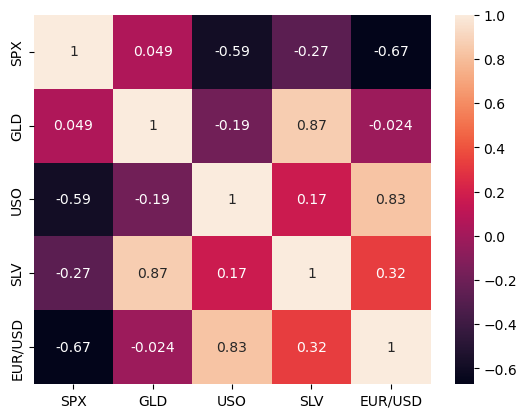

In [16]:
sns.heatmap(correlation, annot = True)

In [17]:
# correlation value of  GLD
print(correlation['GLD'])

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


In [27]:
X = df.drop(['Date','GLD'],axis = 1)
y = df['GLD']

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
print(X)

              SPX        USO      SLV   EUR/USD
0     1447.160034  78.470001  15.1800  1.471692
1     1447.160034  78.370003  15.2850  1.474491
2     1411.630005  77.309998  15.1670  1.475492
3     1416.180054  75.500000  15.0530  1.468299
4     1390.189941  76.059998  15.5900  1.557099
...           ...        ...      ...       ...
2285  2671.919922  14.060000  15.5100  1.186789
2286  2697.790039  14.370000  15.5300  1.184722
2287  2723.070068  14.410000  15.7400  1.191753
2288  2730.129883  14.380000  15.5600  1.193118
2289  2725.780029  14.405800  15.4542  1.182033

[2290 rows x 4 columns]


In [30]:
print(y)

0        84.860001
1        85.570000
2        85.129997
3        84.769997
4        86.779999
           ...    
2285    124.589996
2286    124.330002
2287    125.180000
2288    124.489998
2289    122.543800
Name: GLD, Length: 2290, dtype: float64


In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [48]:
model = LinearRegression()

In [49]:
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [50]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

## Evaluate the model

### R² Score (higher is better, maximum = 1)

In [52]:
from sklearn import metrics

train_r2 = metrics.r2_score(y_train, y_train_pred)
test_r2 = metrics.r2_score(y_test, y_test_pred)

print("Training R²:", train_r2)
print("Testing R²:", test_r2)

Training R²: 0.8740001550532462
Testing R²: 0.8957520728068248


### Mean Absolute Error (MAE)

In [53]:
mae = metrics.mean_absolute_error(y_test, y_test_pred)
print("MAE:", mae)

MAE: 5.793144598597279


### Mean Squared Error (MSE)

In [54]:
mse = metrics.mean_squared_error(y_test, y_test_pred)
print("MSE:", mse)

MSE: 56.553455697902294


### Root Mean Squared Error (RMSE)

In [55]:
import numpy as np

rmse = np.sqrt(metrics.mean_squared_error(y_test, y_test_pred))
print("RMSE:", rmse)

RMSE: 7.520203168658563


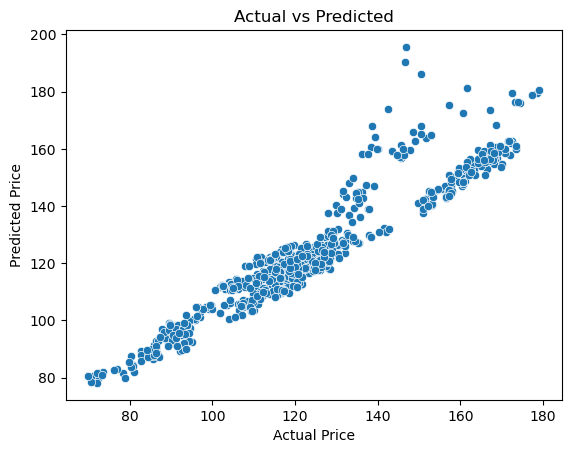

In [58]:
import matplotlib.pyplot as plt

sns.scatterplot(x = y_test, y = y_test_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

# Apply RandomForestRegressor

In [76]:
from sklearn.ensemble import RandomForestRegressor

In [77]:
rnd_forest = RandomForestRegressor(n_estimators = 100)

In [78]:
rnd_forest.fit(X_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [79]:
# model evaluation
pred_train_rand = rnd_forest.predict(X_train)
pred_train_rand 

array([123.2797985 , 118.41220003, 119.85329954, ..., 152.85119667,
       119.3385995 , 165.75189612], shape=(1534,))

In [80]:
# model evaluation
pred_test_rand = rnd_forest.predict(X_test)
pred_test_rand 

array([122.5608998 , 131.44450347, 127.80020031,  97.41819916,
       119.06040022, 114.39189944, 124.77180137, 117.79609943,
       107.87240105,  99.17819981,  95.92769994, 167.40419877,
       147.99260121, 116.3515004 , 170.82220187,  85.00489903,
       124.05969903, 108.84429708, 112.20020079, 131.50370247,
       124.24109912, 113.73720048, 116.03940132, 108.36919888,
       107.79359967, 125.87319955, 119.30489985, 112.48229927,
       113.4904017 , 126.04579895, 146.36530185,  89.27789975,
       167.06129969, 113.56439973, 108.25190053, 120.04370114,
       141.13239812, 161.13710167, 173.55039885, 153.23980145,
       119.79760081, 112.00400079, 121.45719924, 113.79229928,
       122.22747638, 107.88370062,  88.33549876, 114.24739915,
       131.24160227, 117.95070109, 105.16729984, 131.29810228,
       107.291698  , 160.5465045 , 131.70470079, 117.42619959,
       147.00899909, 135.9942018 ,  95.41480039, 124.61910113,
       114.58049958,  86.50380124, 104.22129927, 113.84

In [81]:
# r square error
from sklearn import metrics

train_r2 = metrics.r2_score(y_train,pred_train_rand )
test_r2 = metrics.r2_score(y_test, pred_test_rand)

print("Training R²:", train_r2)
print("Testing R²:", test_r2)

Training R²: 0.9983059984120598
Testing R²: 0.9906883190740673


In [87]:
# Mean Absolute Error (MAE)
mae = metrics.mean_absolute_error(y_test, pred_test_rand)
print("MAE:", mae)

MAE: 1.3326900152116443


In [89]:
# Mean Squared Error (MSE)
mse = metrics.mean_squared_error(y_test,pred_test_rand)
print("MSE:", mse)

MSE: 5.0514935778235275


In [92]:
# Root Mean Squared Error (RMSE)¶
import numpy as np
rmse = np.sqrt(metrics.mean_squared_error(y_test,pred_test_rand))
print("RMSE:", rmse)

RMSE: 2.247552797560833


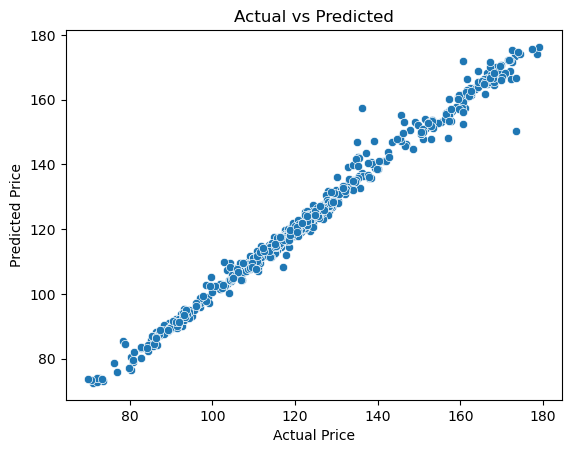

In [93]:
import matplotlib.pyplot as plt

sns.scatterplot(x = y_test, y = pred_test_rand)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()